# Phase 2 — Le test d'acceptation du Bureau

## Objectifs

- Construire un montage PyTorch minimal de classification de textes.
- Utiliser huit relevés réels portant une forme exploitable.
- Entraîner uniquement sur ces huit relevés jusqu'à les apprendre par cœur.
- Produire la courbe de perte complète, les huit prédictions finales et le nombre d'itérations nécessaires.

> Ce test ne mesure pas la généralisation. Il vérifie uniquement que le montage peut apprendre un signal sur un petit ensemble d'exemples.


## 1. Imports

In [1]:
from pathlib import Path
import csv
import random
import re
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn


## 2. Configuration et reproductibilité

Les graines aléatoires sont fixées afin d'obtenir un essai reproductible. Le test est exécuté sur CPU avec PyTorch.


In [2]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

URL_DATA = (
    "https://raw.githubusercontent.com/planetsig/ufo-reports/master/"
    "csv-data/ufo-complete-geocoded-time-standardized.csv"
)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE2_DIR = OUTPUT_DIR / "phase_2_test_acceptation"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime",
    "city",
    "state",
    "country",
    "shape",
    "duration_seconds",
    "duration_hours_min",
    "comments",
    "date_posted",
    "latitude",
    "longitude",
]


## 3. Téléchargement de la transmission

In [3]:
if not DATA_PATH.exists():
    print("Téléchargement du fichier...")
    urllib.request.urlretrieve(URL_DATA, DATA_PATH)
    print("Téléchargement terminé.")
else:
    print(f"Fichier déjà disponible : {DATA_PATH}")


Fichier déjà disponible : ..\data\releves_klaxo3.csv


## 4. Chargement robuste des relevés

Les lignes contenant exactement onze champs sont chargées. Les autres sont mises à part afin de ne pas perdre silencieusement d'information.


In [4]:
lignes_valides = []
lignes_problemes = []

with open(
    DATA_PATH,
    "r",
    encoding="utf-8",
    errors="replace",
    newline="",
) as f:
    reader = csv.reader(f)

    for numero_ligne, row in enumerate(reader, start=1):
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
        else:
            lignes_problemes.append(
                {
                    "numero_ligne": numero_ligne,
                    "nombre_champs": len(row),
                    "contenu": row,
                }
            )

df = pd.DataFrame(lignes_valides, columns=COLUMNS)

print(f"Lignes chargées : {len(df)}")
print(f"Lignes mises à part : {len(lignes_problemes)}")


Lignes chargées : 88679
Lignes mises à part : 196


## 5. Préparation des relevés exploitables

Le test utilise uniquement des commentaires non vides et des formes renseignées. Les classes `unknown` et `other` sont exclues pour ce test car elles ne décrivent pas une forme spécifique.


In [5]:
df["comments_clean"] = (
    df["comments"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["shape_clean"] = (
    df["shape"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

df_exploitable = df.loc[
    (df["comments_clean"].ne(""))
    & (df["shape_clean"].ne(""))
    & (~df["shape_clean"].isin(["unknown", "other"]))
] .copy()

print(f"Relevés exploitables : {len(df_exploitable)}")
print(f"Nombre de formes exploitables : {df_exploitable['shape_clean'].nunique()}")


Relevés exploitables : 73183
Nombre de formes exploitables : 27


## 6. Sélection de huit relevés réels

Huit classes différentes sont sélectionnées. Pour chaque classe, un témoignage réel est tiré avec une graine fixe. L'objectif est de vérifier que le modèle sait les mémoriser.


In [6]:
formes_test = [
    "light",
    "triangle",
    "circle",
    "fireball",
    "disk",
    "sphere",
    "oval",
    "cigar",
]

huit_releves = (
    df_exploitable
    .loc[df_exploitable["shape_clean"].isin(formes_test)]
    .groupby("shape_clean", group_keys=False)
    .sample(n=1, random_state=SEED)
    .sort_values("shape_clean")
    .reset_index()
)

assert len(huit_releves) == 8

huit_releves[[
    "index",
    "shape_clean",
    "comments_clean",
]]


,index,shape_clean,comments_clean
0,36199,cigar,A bar like object sighted in India which was ...
1,46049,circle,ufo seen by the US Coast Guard Cutter Laurel
2,2992,disk,Saucer shaped aircraft taking off. Unbelievabl...
3,44002,fireball,From the siting you would be able to determine...
4,13921,light,3 bright white lights in traingular formation ...
5,51634,oval,Light in the sky that can stop moving&#44 move...
6,53372,sphere,2 sightings in Germany
7,79227,triangle,UFO Sighting on Route 422 near Oaks


## 7. Tokenisation simple

La tokenisation utilisée est volontairement simple : elle transforme le texte en minuscules et extrait les mots alphanumériques. Un vocabulaire est construit uniquement à partir des huit témoignages du test d'acceptation.


In [7]:
def tokenizer(texte):
    return re.findall(
        r"[a-z0-9]+",
        str(texte).lower(),
    )

vocabulaire = {"<PAD>": 0, "<UNK>": 1}

for commentaire in huit_releves["comments_clean"]:
    for token in tokenizer(commentaire):
        if token not in vocabulaire:
            vocabulaire[token] = len(vocabulaire)

print(f"Taille du vocabulaire : {len(vocabulaire)}")
print(vocabulaire)


Taille du vocabulaire : 93
{'<PAD>': 0, '<UNK>': 1, 'a': 2, 'bar': 3, 'like': 4, 'object': 5, 'sighted': 6, 'in': 7, 'india': 8, 'which': 9, 'was': 10, 'stand': 11, 'still': 12, 'position': 13, 'illuminating': 14, 'light': 15, 'downwards': 16, 'on': 17, 'to': 18, 'ground': 19, 'ufo': 20, 'seen': 21, 'by': 22, 'the': 23, 'us': 24, 'coast': 25, 'guard': 26, 'cutter': 27, 'laurel': 28, 'saucer': 29, 'shaped': 30, 'aircraft': 31, 'taking': 32, 'off': 33, 'unbelievable': 34, 'acceleration': 35, 'bluish': 36, 'neon': 37, 'round': 38, 'glow': 39, 'underneath': 40, 'from': 41, 'siting': 42, 'you': 43, 'would': 44, 'be': 45, 'able': 46, 'determine': 47, 'where': 48, 'it': 49, 'entered': 50, 'and': 51, 'how': 52, 'low': 53, 'before': 54, 'vanished': 55, '3': 56, 'bright': 57, 'white': 58, 'lights': 59, 'traingular': 60, 'formation': 61, 'with': 62, 'no': 63, 'sound': 64, 'seemingly': 65, 'fixed': 66, 'pos': 67, 'nuforc': 68, 'note': 69, 'planets': 70, 'sw': 71, 'sky': 72, 'pd': 73, 'that': 74, '

## 8. Encodage des textes et des classes

Les textes sont convertis en identifiants de tokens. Les formes sont converties en identifiants de classes.


In [8]:
classes = sorted(huit_releves["shape_clean"].unique())
classe_vers_id = {classe: index for index, classe in enumerate(classes)}
id_vers_classe = {index: classe for classe, index in classe_vers_id.items()}

def encoder_texte(texte):
    tokens = tokenizer(texte)
    return [vocabulaire.get(token, vocabulaire["<UNK>"]) for token in tokens]

textes_encodes = [
    encoder_texte(commentaire)
    for commentaire in huit_releves["comments_clean"]
]

labels = torch.tensor(
    [
        classe_vers_id[forme]
        for forme in huit_releves["shape_clean"]
    ],
    dtype=torch.long,
    device=DEVICE,
)

longueurs = torch.tensor(
    [len(texte) for texte in textes_encodes],
    dtype=torch.float32,
    device=DEVICE,
)

tokens_concat = torch.tensor(
    [token for texte in textes_encodes for token in texte],
    dtype=torch.long,
    device=DEVICE,
)

offsets = torch.tensor(
    [0] + [sum(longueurs[:i].int()).item() for i in range(1, len(textes_encodes))],
    dtype=torch.long,
    device=DEVICE,
)

print(f"Classes : {classes}")
print(f"Tokens concaténés : {tokens_concat.shape}")
print(f"Offsets : {offsets}")


Classes : ['cigar', 'circle', 'disk', 'fireball', 'light', 'oval', 'sphere', 'triangle']
Tokens concaténés : torch.Size([119])
Offsets : tensor([  0,  20,  29,  45,  65,  88, 108, 112])


## 9. Modèle PyTorch minimal

Le modèle utilise :

- une couche `EmbeddingBag` pour transformer les tokens en vecteurs et moyenner les vecteurs d'un même texte ;
- une couche linéaire pour prédire la forme.

Ce montage est volontairement petit, car le but est de mémoriser huit exemples et de valider le chemin complet entraînement → gradient → prédiction.


In [9]:
class ModeleAcceptation(nn.Module):
    def __init__(self, taille_vocabulaire, dimension_embedding, nombre_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(
            taille_vocabulaire,
            dimension_embedding,
            mode="mean",
        )
        self.classifier = nn.Linear(
            dimension_embedding,
            nombre_classes,
        )

    def forward(self, tokens, offsets):
        vecteurs_textes = self.embedding(tokens, offsets)
        return self.classifier(vecteurs_textes)

modele = ModeleAcceptation(
    taille_vocabulaire=len(vocabulaire),
    dimension_embedding=64,
    nombre_classes=len(classes),
).to(DEVICE)

modele


ModeleAcceptation(
  (embedding): EmbeddingBag(93, 64, mode='mean')
  (classifier): Linear(in_features=64, out_features=8, bias=True)
)

## 10. Entraînement jusqu'à mémorisation

Le modèle est entraîné sur les huit mêmes exemples. L'entraînement s'arrête lorsque les huit prédictions sont correctes ou lorsque la limite maximale d'itérations est atteinte.


In [10]:
fonction_perte = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(
    modele.parameters(),
    lr=0.05,
)

MAX_ITERATIONS = 3000
pertes = []
iterations = []
iteration_reussite = None

for iteration in range(1, MAX_ITERATIONS + 1):
    modele.train()
    optimiseur.zero_grad()

    logits = modele(tokens_concat, offsets)
    perte = fonction_perte(logits, labels)

    perte.backward()
    optimiseur.step()

    pertes.append(perte.item())
    iterations.append(iteration)

    with torch.no_grad():
        predictions = logits.argmax(dim=1)
        nombre_correct = int((predictions == labels).sum().item())

    if nombre_correct == len(labels):
        iteration_reussite = iteration
        break

print(f"Nombre d'itérations exécutées : {len(iterations)}")
print(f"Nombre de prédictions correctes : {nombre_correct} / {len(labels)}")


Nombre d'itérations exécutées : 2
Nombre de prédictions correctes : 8 / 8


## 11. Courbe de perte

La perte doit diminuer pendant l'entraînement. La courbe est enregistrée afin d'être intégrée au rapport.


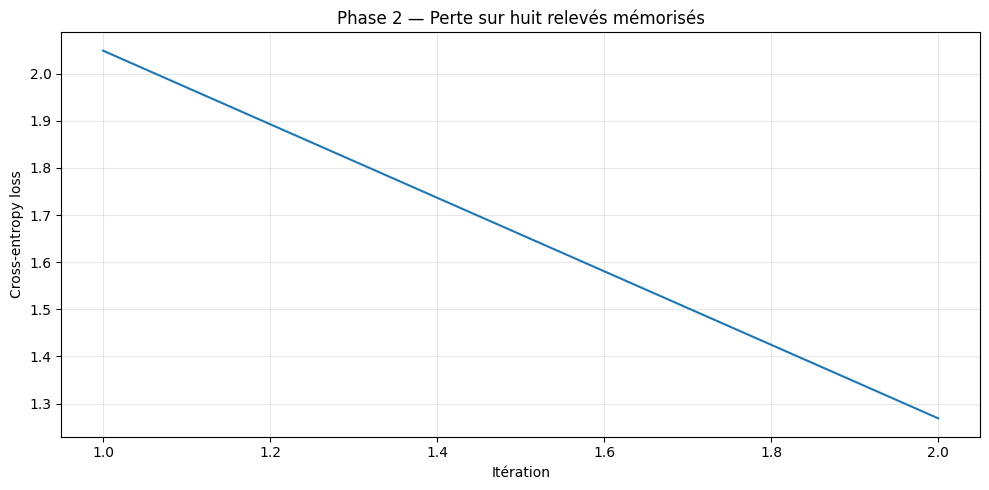

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(iterations, pertes, color="tab:blue")
plt.title("Phase 2 — Perte sur huit relevés mémorisés")
plt.xlabel("Itération")
plt.ylabel("Cross-entropy loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    PHASE2_DIR / "courbe_perte_8_releves.png",
    dpi=150,
)

plt.show()


## 12. Prédictions finales

Les huit prédictions finales sont affichées à côté des huit formes réelles. Le test est validé si toutes les lignes sont correctes.


In [12]:
modele.eval()

with torch.no_grad():
    logits_finaux = modele(tokens_concat, offsets)
    predictions_finales = logits_finaux.argmax(dim=1).cpu().tolist()
    probabilites_finales = torch.softmax(logits_finaux, dim=1).cpu()

table_predictions = huit_releves[
    ["index", "comments_clean", "shape_clean"]
] .copy()

table_predictions["forme_predite"] = [
    id_vers_classe[prediction]
    for prediction in predictions_finales
]

table_predictions["correct"] = (
    table_predictions["shape_clean"]
    == table_predictions["forme_predite"]
)

table_predictions["probabilite_forme_predite"] = [
    float(probabilites_finales[i, predictions_finales[i]])
    for i in range(len(predictions_finales))
]

table_predictions


,index,comments_clean,shape_clean,forme_predite,correct,probabilite_forme_predite
0,36199,A bar like object sighted in India which was ...,cigar,cigar,True,0.328921
1,46049,ufo seen by the US Coast Guard Cutter Laurel,circle,circle,True,0.531077
2,2992,Saucer shaped aircraft taking off. Unbelievabl...,disk,disk,True,0.458280
3,44002,From the siting you would be able to determine...,fireball,fireball,True,0.472229
4,13921,3 bright white lights in traingular formation ...,light,light,True,0.428749
5,51634,Light in the sky that can stop moving&#44 move...,oval,oval,True,0.458039
6,53372,2 sightings in Germany,sphere,sphere,True,0.816782
7,79227,UFO Sighting on Route 422 near Oaks,triangle,triangle,True,0.677579


## 13. Vérification du test d'acceptation

In [13]:
nombre_correct_final = int(table_predictions["correct"].sum())
test_accepte = nombre_correct_final == len(table_predictions)

print(f"Prédictions correctes finales : {nombre_correct_final} / {len(table_predictions)}")
print(f"Test d'acceptation réussi : {test_accepte}")

assert test_accepte, (
    "Le modèle n'a pas encore mémorisé les huit relevés. "
    "Augmente MAX_ITERATIONS ou ajuste le learning rate."
)


Prédictions correctes finales : 8 / 8
Test d'acceptation réussi : True


## 14. Export des résultats

In [14]:
table_predictions.to_csv(
    PHASE2_DIR / "predictions_finales_8_releves.csv",
    index=False,
)

pd.DataFrame(
    {
        "iteration": iterations,
        "perte": pertes,
    }
).to_csv(
    PHASE2_DIR / "historique_perte_8_releves.csv",
    index=False,
)

resume_phase2 = pd.DataFrame(
    [
        {
            "nombre_releves": len(table_predictions),
            "nombre_classes": len(classes),
            "classes": ", ".join(classes),
            "iterations_executees": len(iterations),
            "iteration_reussite": iteration_reussite,
            "perte_finale": pertes[-1],
            "predictions_correctes": nombre_correct_final,
            "test_accepte": test_accepte,
        }
    ]
)

resume_phase2.to_csv(
    PHASE2_DIR / "resume_phase2.csv",
    index=False,
)

print("Fichiers exportés dans :")
print(PHASE2_DIR)


Fichiers exportés dans :
..\outputs\phase_2_test_acceptation
